# CH 5 - 6 : HYPOTHESIS TESTS VERSUS CONFIDENCE INTERVALS - POTENTIAL CONFLICT

> **Eurêka final :** un test d'hypothèse répond à la question **“est-ce que le profit observé est trop rare pour être attribué au hasard ?”**, tandis qu'un **intervalle de confiance** répond à la question **“quelle fourchette réaliste peut contenir l'espérance future ?”**.

Dans la plupart des cas, ces deux outils racontent la même histoire.

Mais si la **distribution d'échantillonnage** est fortement **asymétrique**, ils peuvent envoyer deux signaux contradictoires :

- la **p-value** peut valider la règle ;
- l'**intervalle de confiance** peut encore inclure une espérance négative.

Ce chapitre est donc une leçon de prudence EBTA : **la signification statistique ne suffit pas toujours**.


## 1. Le problème en une phrase

Un **test d'hypothèse** et un **intervalle de confiance** peuvent parfois aboutir à des conclusions différentes sur la même règle de trading.

> Une stratégie peut être jugée **statistiquement significative**, tout en ayant un **intervalle de confiance** dont la borne basse passe sous zéro.

En langage trader :

| Outil | Question posée | Réponse possible |
|---|---:|---|
| **Test d'hypothèse** | Mon profit est-il trop rare sous l'hypothèse du hasard ? | Oui, donc je rejette $H_0$ |
| **Intervalle de confiance** | Quelle est la zone plausible de mon rendement futur réel ? | Elle inclut encore des valeurs négatives |

Le conflit ne veut pas dire que les mathématiques sont fausses.

Il veut dire que les deux outils regardent **deux zones différentes** de la distribution.


## 2. Rappel : le test d'hypothèse

En trading EBTA, on part souvent de l'hypothèse nulle :

$$
H_0 : \mu \le 0
$$

où $\mu$ représente l'**espérance réelle future** de la stratégie.

Le test cherche à savoir si le rendement moyen observé dans le **backtest**, noté $\bar{X}$, est suffisamment élevé pour être improbable sous $H_0$.

La logique est :

$$
\text{p-value} = P(\bar{X}_{\text{hasard}} \ge \bar{X}_{\text{observé}} \mid H_0)
$$

Si cette probabilité est inférieure à $5\%$, on rejette $H_0$.

$$
\text{p-value} < 0.05 \Rightarrow \text{rejet de } H_0
$$

> Le test d'hypothèse regarde surtout la **queue droite** de la distribution : les profits très élevés que le hasard pourrait produire.


## 3. Rappel : l'intervalle de confiance

Un **intervalle de confiance** cherche à construire une fourchette plausible pour $\mu$.

Exemple :

$$
IC_{90\%} = [\text{borne basse}, \text{borne haute}]
$$

Si la borne basse est au-dessus de zéro :

$$
\text{borne basse} > 0
$$

alors la stratégie semble robuste, car même le scénario prudent reste positif.

Mais si la borne basse passe sous zéro :

$$
\text{borne basse} < 0
$$

alors il existe encore une zone plausible où l'espérance future réelle est négative.

> L'intervalle de confiance regarde surtout la **queue gauche** : le scénario défavorable compatible avec les données observées.


## 4. Pourquoi les deux peuvent entrer en conflit

En théorie, pour une distribution **symétrique**, un test unilatéral à $5\%$ et un intervalle de confiance à $90\%$ devraient être cohérents.

Mais en trading, la distribution des rendements peut être **asymétrique**.

C'est souvent le cas avec :

- des stratégies à petits gains fréquents et grosses pertes rares ;
- des stop-loss larges ;
- des take-profits serrés ;
- des queues de distribution épaisses ;
- des événements extrêmes.

La source du conflit est donc la **skewness**, c'est-à-dire l'asymétrie.

| Distribution | Conséquence |
|---|---|
| **Symétrique** | Test et IC racontent souvent la même histoire |
| **Asymétrique à gauche** | Le test peut valider, mais l'IC peut rester dangereux |
| **Asymétrique à droite** | Le conflit peut apparaître dans l'autre sens selon la construction |

> **Eurêka :** le test ne regarde pas le même côté de la distribution que l'intervalle de confiance.


## 5. Intuition visuelle

Imagine une distribution d'échantillonnage avec une **queue gauche très longue**.

Cela signifie :

- les pertes extrêmes sont rares, mais possibles ;
- la queue droite peut être courte ;
- un profit observé peut paraître très rare du côté droit ;
- pourtant, l'incertitude vers le bas reste grande.

Donc le test dit :

> “Ton profit est trop haut pour être expliqué par le hasard.”

Mais l'intervalle de confiance dit :

> “Oui, mais la borne prudente de ton rendement futur peut encore être négative.”

C'est exactement le paradoxe présenté dans cette section.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres pédagogiques
n_obs = 250
n_bootstrap = 20_000

# On simule une stratégie avec beaucoup de petits gains
# et quelques grosses pertes rares : asymétrie négative.
small_gains = np.random.normal(loc=0.0008, scale=0.003, size=n_obs)
rare_losses_mask = np.random.rand(n_obs) < 0.04
rare_losses = np.random.normal(loc=-0.025, scale=0.01, size=n_obs)

returns = np.where(rare_losses_mask, rare_losses, small_gains)

observed_mean = returns.mean()

observed_mean


np.float64(-0.000147449426266296)

## 6. Bootstrap de la moyenne

Nous allons maintenant construire une distribution bootstrap de la **moyenne des rendements**.

Le principe :

1. on garde les rendements observés ;
2. on tire au hasard avec remise ;
3. on calcule une moyenne ;
4. on répète des milliers de fois ;
5. on observe la distribution des moyennes simulées.

Cette distribution donne une approximation de l'incertitude autour de la performance moyenne.


In [47]:
bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    sample = np.random.choice(returns, size=n_obs, replace=True)
    bootstrap_means[i] = sample.mean()

bootstrap_summary = pd.Series(bootstrap_means).describe(percentiles=[0.05, 0.10, 0.50, 0.90, 0.95])
bootstrap_summary


count    20000.000000
mean        -0.000156
std          0.000379
min         -0.001758
5%          -0.000805
10%         -0.000657
50%         -0.000142
90%          0.000322
95%          0.000444
max          0.001107
dtype: float64

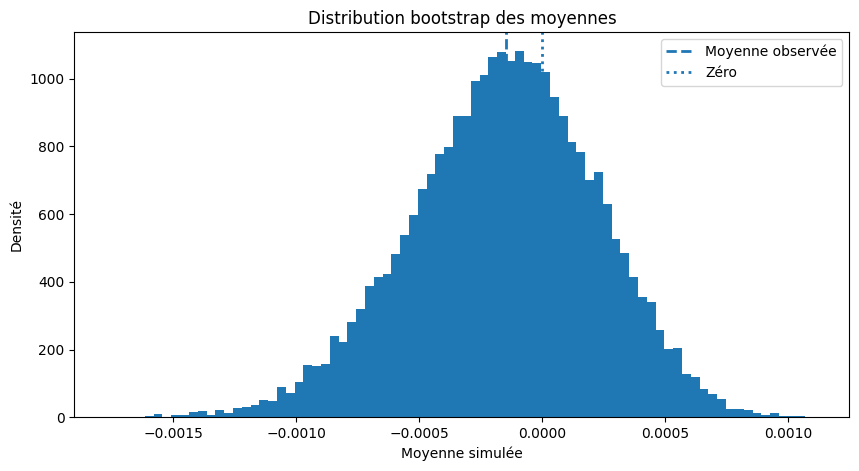

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=80, density=True)
plt.axvline(observed_mean, linestyle="--", linewidth=2, label="Moyenne observée")
plt.axvline(0, linestyle=":", linewidth=2, label="Zéro")
plt.title("Distribution bootstrap des moyennes")
plt.xlabel("Moyenne simulée")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 7. Calcul de la p-value

Pour simplifier, on teste ici si la moyenne observée est rare par rapport à une distribution nulle centrée sur zéro.

On recentre donc les rendements pour créer un monde où la stratégie n'a pas d'espérance positive.

$$
H_0 : \mu = 0
$$

Puis on calcule :

$$
\text{p-value} = P(\bar{X}_{H_0} \ge \bar{X}_{\text{observé}})
$$


In [49]:
# Création d'un monde nul : même forme de distribution, mais moyenne recentrée à zéro
null_returns = returns - observed_mean

null_bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    sample = np.random.choice(null_returns, size=n_obs, replace=True)
    null_bootstrap_means[i] = sample.mean()

p_value = np.mean(null_bootstrap_means >= observed_mean)

p_value


np.float64(0.6621)

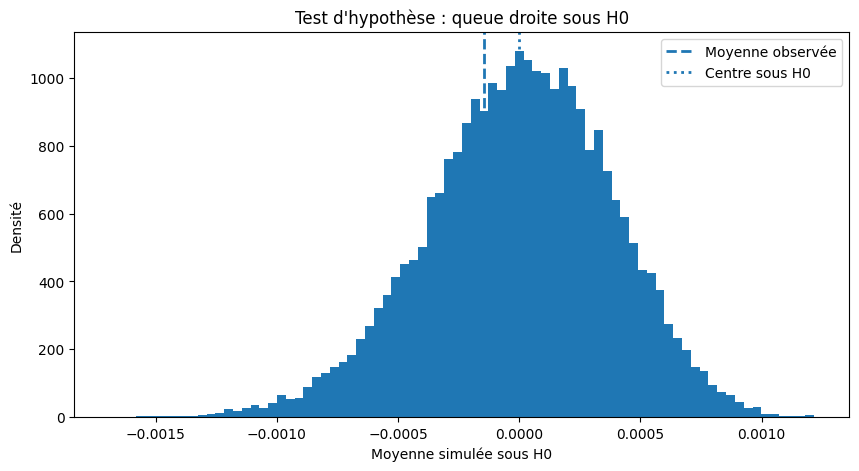

In [50]:
plt.figure(figsize=(10, 5))
plt.hist(null_bootstrap_means, bins=80, density=True)
plt.axvline(observed_mean, linestyle="--", linewidth=2, label="Moyenne observée")
plt.axvline(0, linestyle=":", linewidth=2, label="Centre sous H0")
plt.title("Test d'hypothèse : queue droite sous H0")
plt.xlabel("Moyenne simulée sous H0")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 8. Calcul de l'intervalle de confiance bootstrap

Avec la méthode des centiles bootstrap, un intervalle de confiance à $90\%$ se calcule avec :

$$
IC_{90\%} = [q_{5\%}, q_{95\%}]
$$

où $q_{5\%}$ est le 5e centile de la distribution bootstrap et $q_{95\%}$ le 95e centile.

La question EBTA devient :

> La borne basse de l'IC est-elle au-dessus de zéro ?


In [51]:
ci_low, ci_high = np.percentile(bootstrap_means, [5, 95])

result = pd.DataFrame({
    "Mesure": [
        "Moyenne observée",
        "p-value unilatérale",
        "Borne basse IC 90%",
        "Borne haute IC 90%",
        "Décision test p < 0.05",
        "IC entièrement positif"
    ],
    "Valeur": [
        observed_mean,
        p_value,
        ci_low,
        ci_high,
        p_value < 0.05,
        ci_low > 0
    ]
})

result


,Mesure,Valeur
0,Moyenne observée,-0.000147
1,p-value unilatérale,0.6621
2,Borne basse IC 90%,-0.000805
3,Borne haute IC 90%,0.000444
4,Décision test p < 0.05,False
5,IC entièrement positif,False


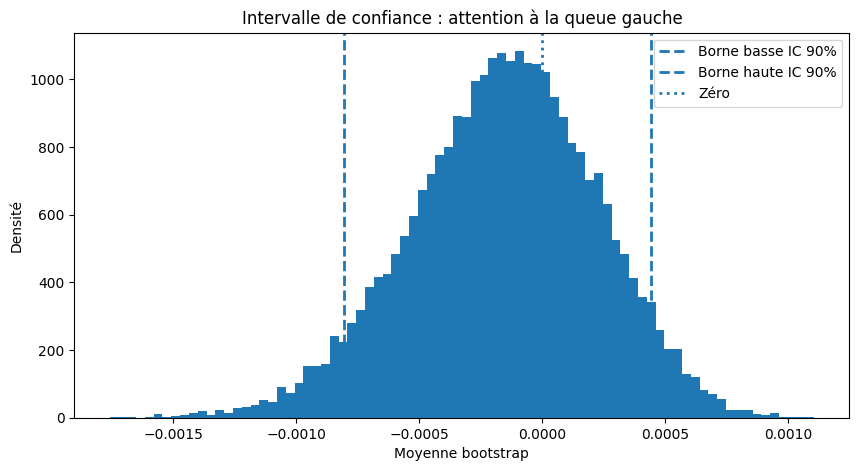

In [52]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=80, density=True)
plt.axvline(ci_low, linestyle="--", linewidth=2, label="Borne basse IC 90%")
plt.axvline(ci_high, linestyle="--", linewidth=2, label="Borne haute IC 90%")
plt.axvline(0, linestyle=":", linewidth=2, label="Zéro")
plt.title("Intervalle de confiance : attention à la queue gauche")
plt.xlabel("Moyenne bootstrap")
plt.ylabel("Densité")
plt.legend()
plt.show()


## 9. Lecture EBTA du résultat

Il faut lire le résultat avec deux filtres.

### Filtre 1 : la p-value

Si la p-value est inférieure à $0.05$, le test dit :

$$
\text{p-value} < 0.05 \Rightarrow \text{résultat statistiquement significatif}
$$

Cela signifie que la moyenne observée est difficile à expliquer par le hasard dans le monde nul.

### Filtre 2 : l'intervalle de confiance

Si la borne basse de l'IC est inférieure à zéro :

$$
\text{borne basse} < 0
$$

alors il reste une zone plausible où l'espérance future est négative.

> **Conclusion prudente :** en cas de conflit, il ne faut pas crier victoire trop vite. La règle peut être intéressante, mais elle n'est pas encore totalement sécurisée du point de vue de l'estimation.


## 10. Pourquoi le Théorème Central Limite réduit ce conflit

Le **Théorème Central Limite** dit que la distribution d'échantillonnage de la moyenne tend vers une forme normale quand la taille d'échantillon augmente.

En simplifié :

$$
N \uparrow \Rightarrow \text{distribution de } \bar{X} \text{ plus symétrique}
$$

Donc avec un grand nombre d'observations :

- la distribution des moyennes devient plus régulière ;
- les queues deviennent moins déséquilibrées ;
- le test et l'IC ont plus de chances de donner le même verdict.

Mais attention :

> Le CLT aide beaucoup, mais il ne transforme pas une stratégie dangereuse en stratégie robuste.

Si les rendements sont très extrêmes, très autocorrélés ou non stationnaires, il faut rester prudent.


In [53]:
sample_sizes = [50, 100, 250, 1000]
simulation_results = []

base_population = np.where(
    np.random.rand(100_000) < 0.04,
    np.random.normal(loc=-0.025, scale=0.01, size=100_000),
    np.random.normal(loc=0.0008, scale=0.003, size=100_000)
)

for n in sample_sizes:
    means = []
    for _ in range(5000):
        sample = np.random.choice(base_population, size=n, replace=True)
        means.append(sample.mean())

    means = np.array(means)
    simulation_results.append({
        "N": n,
        "Moyenne des moyennes": means.mean(),
        "Écart-type des moyennes": means.std(),
        "Skewness approximative": pd.Series(means).skew()
    })

pd.DataFrame(simulation_results)


,N,Moyenne des moyennes,Écart-type des moyennes,Skewness approximative
0,50,-0.000227,0.000875,-0.463678
1,100,-0.000207,0.000605,-0.325539
2,250,-0.000204,0.000385,-0.204237
3,1000,-0.000201,0.000193,-0.132369


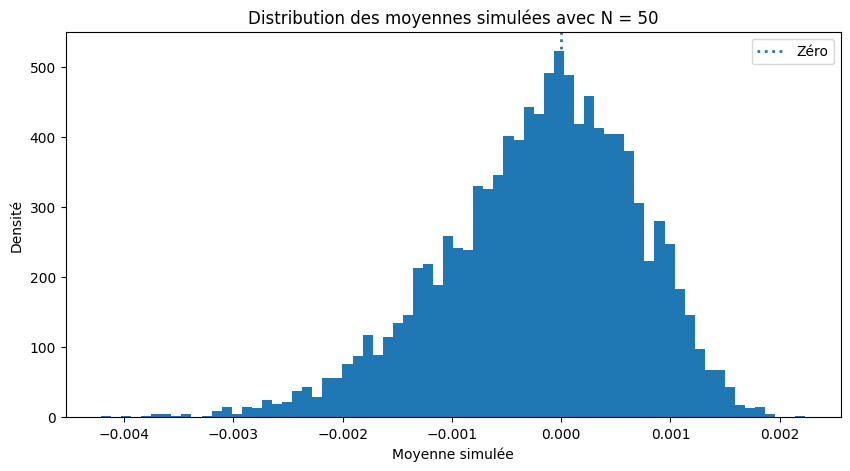

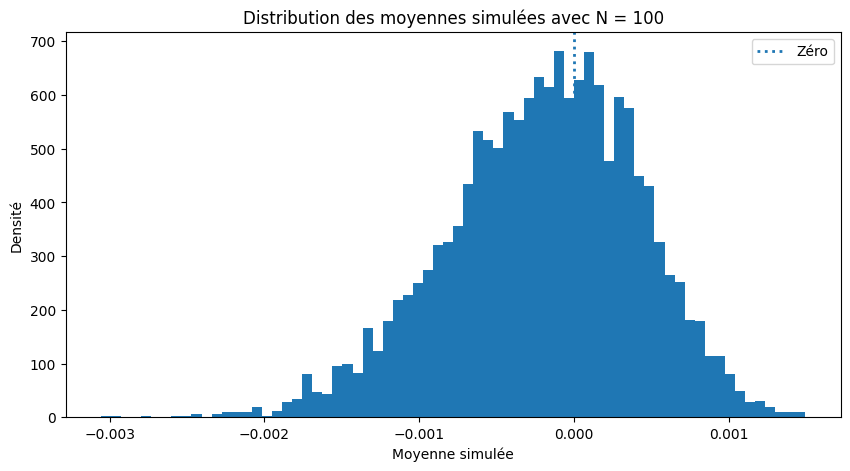

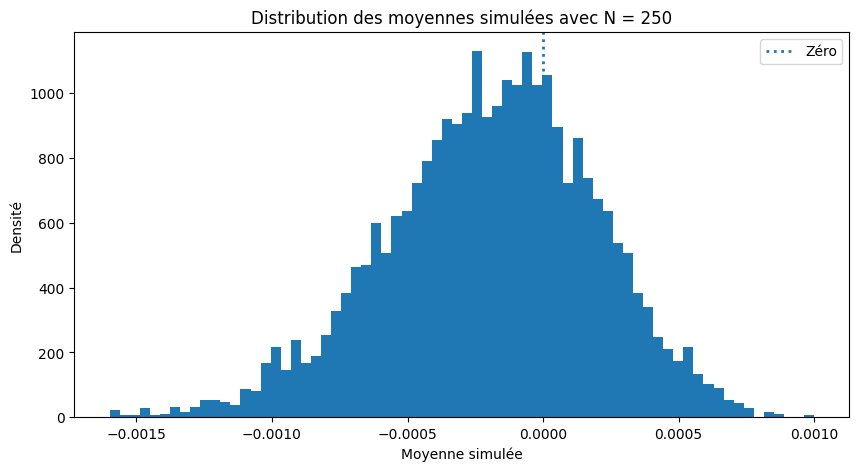

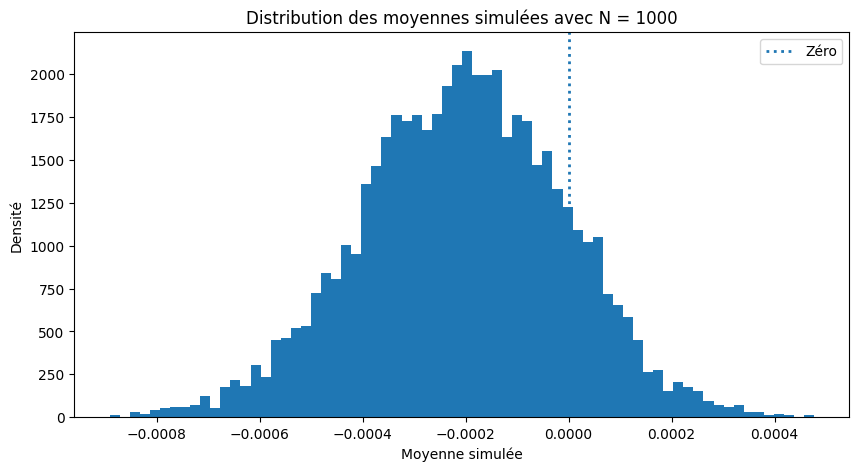

In [54]:
for n in sample_sizes:
    means = []
    for _ in range(5000):
        sample = np.random.choice(base_population, size=n, replace=True)
        means.append(sample.mean())

    plt.figure(figsize=(10, 5))
    plt.hist(means, bins=70, density=True)
    plt.axvline(0, linestyle=":", linewidth=2, label="Zéro")
    plt.title(f"Distribution des moyennes simulées avec N = {n}")
    plt.xlabel("Moyenne simulée")
    plt.ylabel("Densité")
    plt.legend()
    plt.show()


## 11. Checklist de décision EBTA

Avant de valider une règle de trading, ne regarde pas seulement la p-value.

| Contrôle | Question | Verdict prudent |
|---|---|---|
| **p-value** | Est-elle inférieure à $0.05$ ? | Le hasard devient moins crédible |
| **IC 90\%** | La borne basse est-elle au-dessus de zéro ? | L'espérance future semble plus robuste |
| **Skewness** | La distribution est-elle très asymétrique ? | Risque de conflit test vs IC |
| **Taille N** | L'échantillon est-il assez large ? | Le CLT devient plus fiable |
| **Risque extrême** | Existe-t-il de grosses pertes rares ? | Attention aux stratégies faussement propres |

> En EBTA, une règle vraiment solide doit idéalement passer les deux filtres : **signification statistique** et **intervalle de confiance positif**.


## 12. Exemple mental ultra-simple

Supposons une stratégie qui gagne souvent petit, mais perd rarement très gros.

Sur un backtest, elle affiche une moyenne positive.

Le test d'hypothèse peut dire :

> “Ce profit est statistiquement rare sous $H_0$.”

Mais l'IC peut dire :

> “La borne prudente de l'espérance future est encore négative.”

Donc le bon réflexe n'est pas :

> “La p-value est bonne, je trade.”

Le bon réflexe est :

> “La p-value est intéressante, mais je dois vérifier si l'IC confirme que l'espérance future reste positive même dans un scénario prudent.”


## 13. L'Eurêka final

> **Le test d'hypothèse est un détecteur de signal. L'intervalle de confiance est un détecteur de fragilité.**

Le test dit si le résultat semble trop fort pour être attribué au hasard.

L'intervalle de confiance dit jusqu'où l'estimation peut raisonnablement se dégrader.

Donc :

$$
\text{p-value faible} \ne \text{stratégie automatiquement robuste}
$$

Et surtout :

$$
\text{IC avec borne basse négative} = \text{prudence obligatoire}
$$

La vraie mentalité EBTA :

> Je ne cherche pas seulement une stratégie qui **rejette le hasard**. Je cherche une stratégie dont l'**espérance estimée reste défendable**, même après prise en compte de l'incertitude.


## 14. Résumé opérationnel

À retenir absolument :

- Le conflit entre test d'hypothèse et IC vient surtout de l'**asymétrie**.
- Le test d'hypothèse regarde la **queue droite**.
- L'intervalle de confiance regarde la **queue gauche**.
- Une p-value faible peut coexister avec une borne basse d'IC négative.
- Le **Théorème Central Limite** réduit ce problème quand $N$ augmente.
- En cas de conflit, l'attitude conservatrice consiste à ne pas valider trop vite la règle.

> **Règle EBTA :** une stratégie devient beaucoup plus crédible quand elle combine une **p-value faible**, un **IC positif**, une **distribution raisonnablement symétrique** et un **échantillon suffisamment large**.


## Annexe — Source originale collée

### **CH 5 - 6 : HYPOTHESIS TESTS VERSUS CONFIDENCE INTERVALS - POTENTIAL CONFLICT**

Cette section explore une situation paradoxale où les deux outils de l'inférence statistique (le test d'hypothèse et l'intervalle de confiance) peuvent aboutir à des conclusions opposées concernant la validité d'une règle de trading.

#### **Idées clés :**
*   **Divergence possible :** Un test d'hypothèse peut rejeter la chance (p-value < 0,05) alors que l'intervalle de confiance suggère une possible espérance de gain négative.
*   **Focalisation des queues :** Le conflit provient du fait que le test d'hypothèse se concentre sur la queue droite de la distribution, tandis que l'intervalle de confiance (IC) se concentre sur la queue gauche.
*   **L'asymétrie comme cause :** Ce problème survient uniquement lorsque la distribution d'échantillonnage n'est pas symétrique (distribution asymétrique ou *skewed*).
*   **Le rôle régulateur du CLT :** Grâce au Théorème Central Limite (Central Limit Theorem), ce conflit est rare pour les moyennes de grands échantillons, car la distribution tend naturellement vers la symétrie.

#### **Référence :**
*Hypothesis Tests versus Confidence Intervals: Potential Conflict*, pages 250 à 252.

#### **Citation Directe :**
« It is possible for a hypothesis test and a confidence interval to lead to different conclusions about a rule’s expected return. » (Page 250).

---

#### **Vision Macro :**
L'enjeu est la fiabilité du verdict scientifique. David Aronson explique qu'en théorie, ces deux outils devraient être en parfait accord : si la borne inférieure d'un intervalle de confiance à 90 % est au-dessus de zéro, alors le hasard devrait être rejeté avec une p-value de 0,05. Cependant, le trading réel traite souvent avec des données imparfaites. Ce chapitre avertit le trader EBTA : la "signification statistique" (rejet du hasard) ne garantit pas toujours une sécurité totale contre les pertes si la structure de la distribution des rendements est irrégulière.

---

#### **Vision Micro :**
Le mécanisme de ce conflit repose sur la géométrie de la distribution d'échantillonnage :

1.  **L'asymétrie (Skewness) :** Si la distribution est "étirée" vers la gauche (asymétrie négative), la queue droite (utilisée par le test) peut être très courte et la queue gauche (utilisée par l'IC) très longue.
2.  **Le paradoxe du test :** Parce que la queue droite est courte, le rendement observé peut tomber dans la zone des 5 % supérieurs de la distribution de la chance, entraînant le rejet de $H_0$ (la règle est jugée "bonne").
3.  **Le paradoxe de l'IC :** En déplaçant cette même distribution asymétrique sur le profit réel pour calculer l'intervalle de confiance, la queue gauche (qui est très longue) peut s'étendre bien en dessous de zéro.
4.  **Conséquence :** On se retrouve avec une règle "statistiquement significative" mais dont l'intervalle de confiance indique qu'il y a plus de 5 % de probabilité que le rendement réel futur soit négatif.

---

#### **Résumé Simplifié :**
Parfois, vos statistiques vous envoient des messages contradictoires. Le test d'hypothèse vous dit : "Ton profit est trop bizarre pour être dû au hasard". Mais l'intervalle de confiance vous dit : "Attention, avec mes calculs, tu as encore de fortes chances de perdre de l'argent à l'avenir". Ce "bug" statistique arrive quand vos résultats de trading ne sont pas équilibrés (quand ils ne forment pas une belle courbe en cloche symétrique).

---

#### **Exemple du livre pour mieux comprendre :**
*   **La distribution asymétrique (Figure 5.22) :** Aronson présente une courbe fortement asymétrique vers la gauche. En bas de l'image, le test de $H_0$ montre que le profit est dans la zone rare (< 0,05). En haut de l'image, l'IC à 90 % centré sur ce même profit montre une borne inférieure qui "plonge" sous le zéro. La règle est validée par le test mais reste suspecte selon l'IC.

---

#### **Actions Concrètes :**
*   **Vérifier la symétrie :** Ne vous contentez pas de la p-value ; regardez si la distribution Bootstrap générée est symétrique.
*   **Priorité à la prudence :** En cas de conflit, Aronson suggère qu'une position conservatrice consiste à douter de la règle si l'IC inclut des valeurs négatives.
*   **Augmenter la taille N :** Plus vous testez votre règle sur un grand nombre de jours/trades, plus le Théorème Central Limite rendra votre distribution symétrique, éliminant ainsi ce risque de conflit.

---

#### **À retenir absolument :**
*   Le conflit naît de l'**asymétrie** de la distribution.
*   Test d'hypothèse = focus sur la **queue droite** (rejet de $H_0$).
*   Intervalle de confiance = focus sur la **queue gauche** (mesure du risque de perte).
*   Le **Théorème Central Limite** résout généralement ce problème pour les échantillons larges ($N$ élevé).
*   Un résultat peut être statistiquement "significatif" tout en ayant une borne d'IC **négative**.

J'ai terminé l'analyse du conflit potentiel entre les tests d'hypothèse et les intervalles de confiance selon le protocole EBTA.
```
